In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
json_dir = "https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/"

years = np.arange(1960, 2001, 10) 

file_urls = [json_dir + f"movies-{year}s.json" for year in years]

print(f"Downloaded {len(file_urls)} files.")


Downloaded 5 files.


In [4]:
all_movies = []
cols_to_drop = ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height']

for url in file_urls:
    df_temp = pd.read_json(url)
    
    df_temp = df_temp.drop(columns=cols_to_drop)
    
    df_temp = df_temp.dropna()
    
    all_movies.append(df_temp)

df = pd.concat(all_movies, ignore_index=True)

In [14]:
print(f"Final dataset size: {df.shape}")
df.info()

df.to_csv('movies_backup.csv', index=False)

Final dataset size: (10750, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10750 entries, 0 to 10749
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   title         10750 non-null  object
 1   year          10750 non-null  int64 
 2   cast          10750 non-null  object
 3   genres        10750 non-null  object
 4   is_top_genre  10750 non-null  bool  
dtypes: bool(1), int64(1), object(3)
memory usage: 346.6+ KB


In [15]:
df.head()

,title,year,cast,genres,is_top_genre
0,The 3rd Voice,1960,"[Edmond O'Brien, Laraine Day, Julie London]","[Mystery, Crime, Drama, Noir, Thriller]",True
1,12 to the Moon,1960,"[Ken Clark, Tom Conway]","[Science Fiction, Independent]",False
2,13 Fighting Men,1960,"[Grant Williams, Carole Matthews]","[War, Drama]",True
3,13 Ghosts,1960,"[Charles Herbert, Jo Morrow]","[Horror, Supernatural]",False
4,The Adventures of Huckleberry Finn,1960,"[Tony Randall, Patty McCormack, Eddie Hodges, ...","[Family, Drama]",True


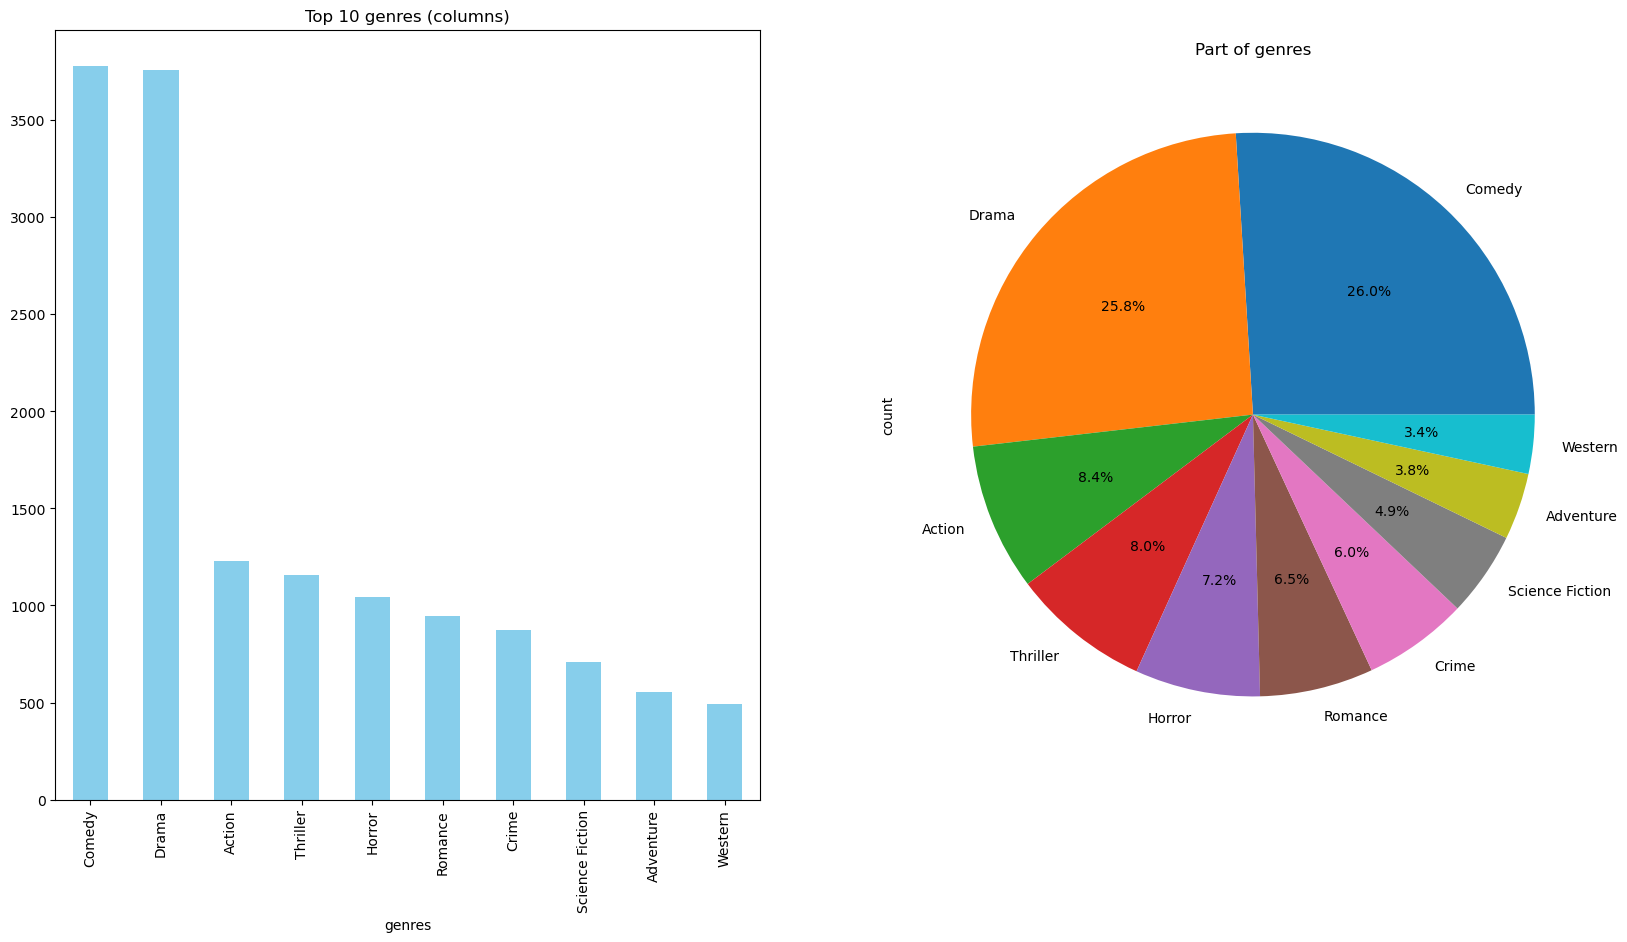

Summary table of genres:
genres
Comedy             3777
Drama              3758
Action             1228
Thriller           1158
Horror             1044
Romance             948
Crime               873
Science Fiction     708
Adventure           556
Western             492
Name: count, dtype: int64


In [6]:
genres_exploded = df.explode('genres')

top_10_genres = genres_exploded['genres'].value_counts().head(10)

# Візуалізація
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
top_10_genres.plot(kind='bar', ax=ax[0], color='skyblue', title='Top 10 genres (columns)')
top_10_genres.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', title='Part of genres')
plt.show()

print("Summary table of genres:")
print(top_10_genres)

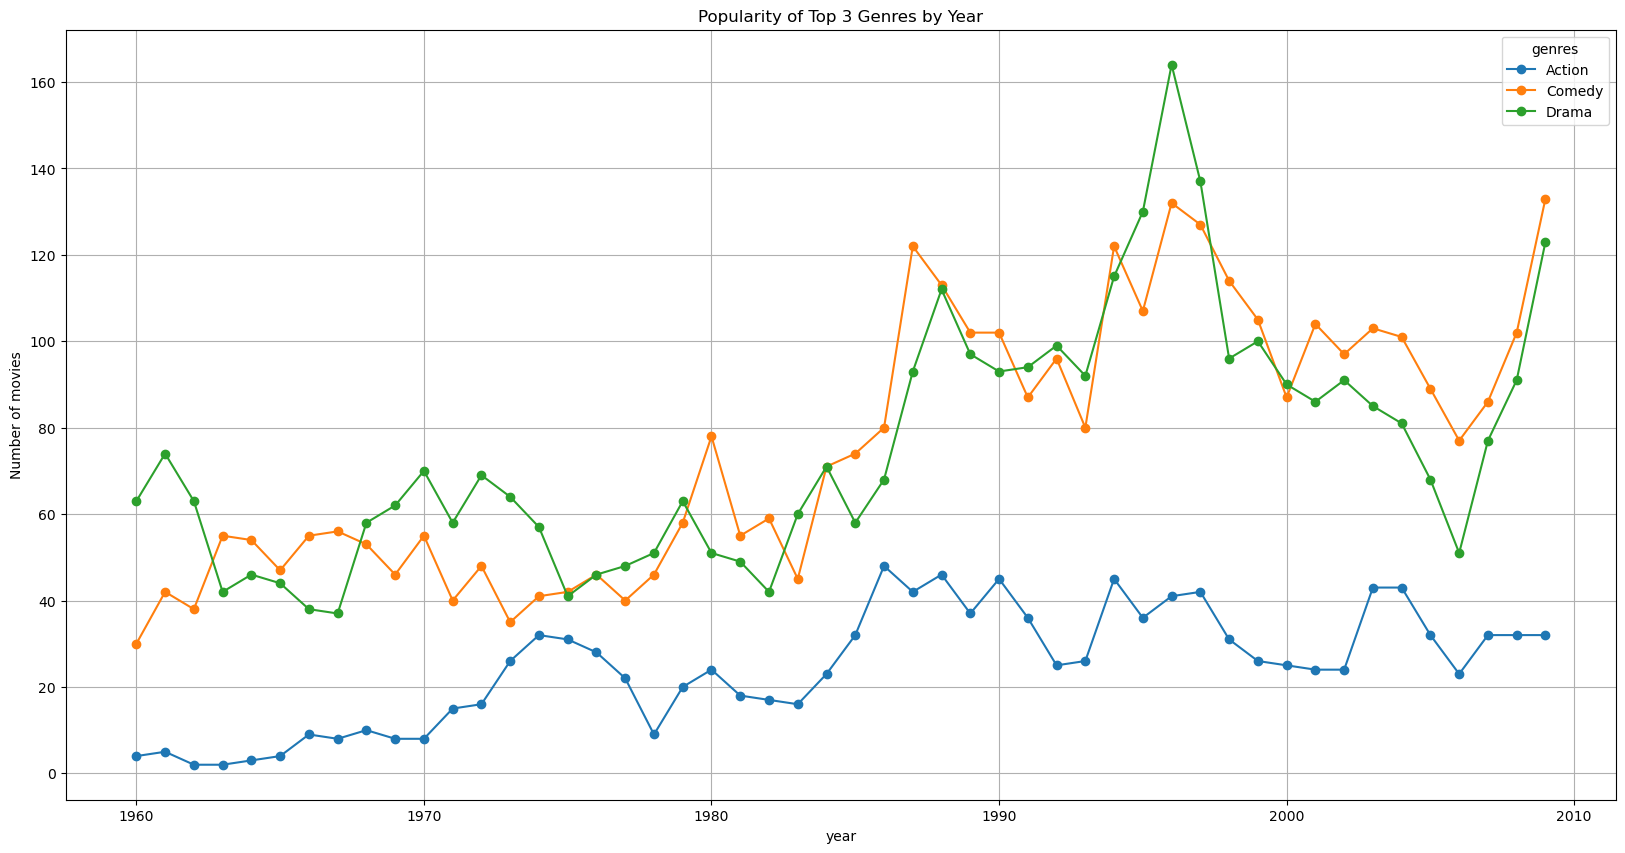

In [16]:
top_3_genres_names = top_10_genres.head(3).index.tolist()

genres_trend = genres_exploded[genres_exploded['genres'].isin(top_3_genres_names)] \
               .groupby(['year', 'genres']).size().unstack(fill_value=0)

genres_trend.plot(kind='line', marker='o', figsize=(20, 10), title='Popularity of Top 3 Genres by Year')
plt.ylabel('Number of movies')
plt.grid(True)
plt.show()

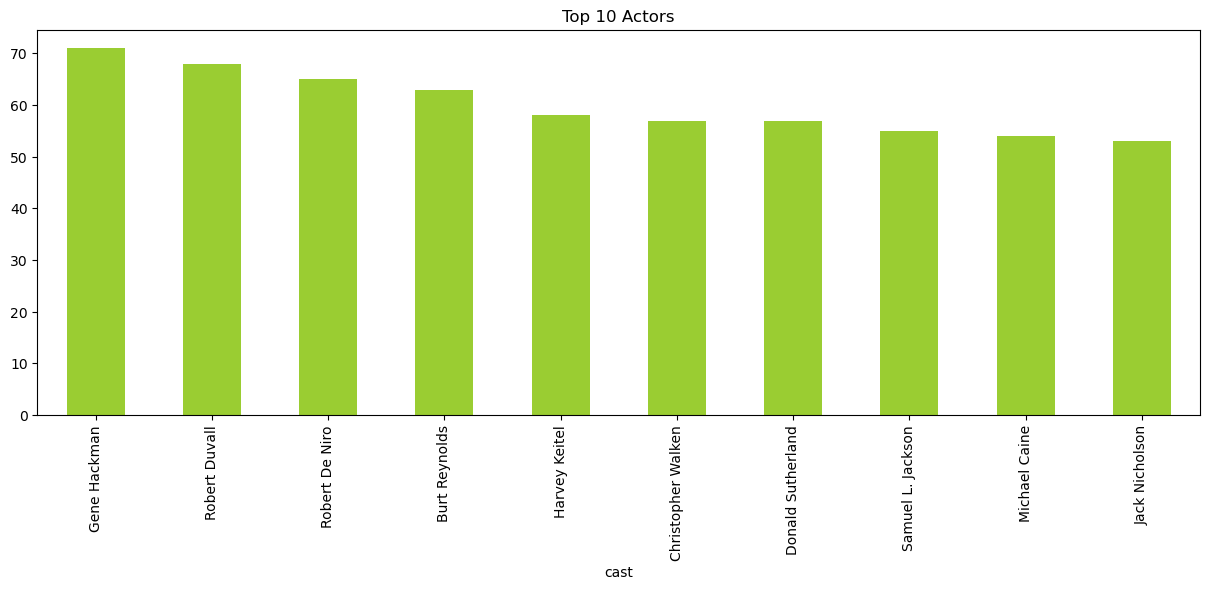

Summary Table: Top 10 Actors
cast
Gene Hackman          71
Robert Duvall         68
Robert De Niro        65
Burt Reynolds         63
Harvey Keitel         58
Christopher Walken    57
Donald Sutherland     57
Samuel L. Jackson     55
Michael Caine         54
Jack Nicholson        53
Name: count, dtype: int64


In [9]:
cast_exploded = df.explode('cast')
top_10_actors = cast_exploded['cast'].value_counts().head(10)

top_10_actors.plot(kind='bar', figsize=(15, 5), color='yellowgreen', title='Top 10 Actors')
plt.show()

print("Summary Table: Top 10 Actors")
print(top_10_actors)

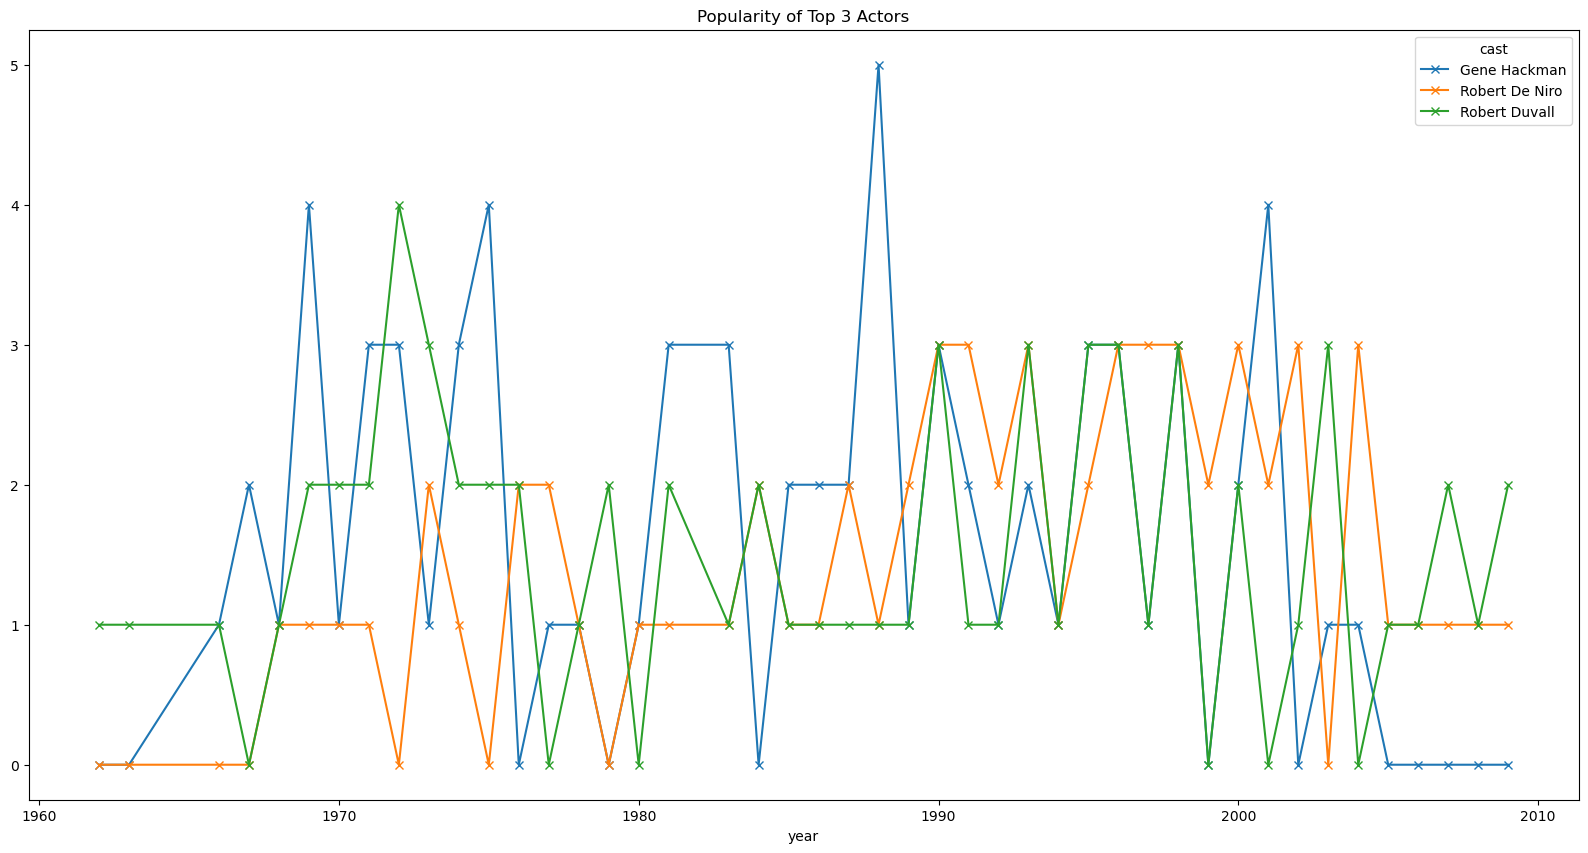

In [10]:
top_3_actors_names = top_10_actors.head(3).index.tolist()
actors_trend = cast_exploded[cast_exploded['cast'].isin(top_3_actors_names)] \
               .groupby(['year', 'cast']).size().unstack(fill_value=0)

actors_trend.plot(kind='line', marker='x', figsize=(20, 10), title='Popularity of Top 3 Actors')
plt.show()

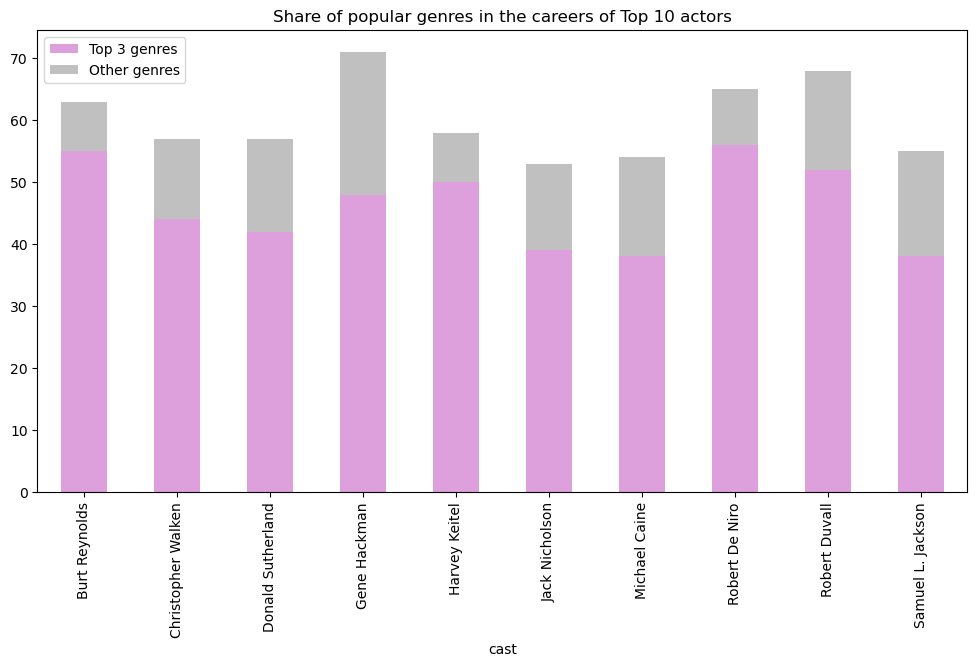

                    Other genres  Top 3 genres  Total  % in Top Genres
cast                                                                  
Burt Reynolds                  8            55     63            87.30
Christopher Walken            13            44     57            77.19
Donald Sutherland             15            42     57            73.68
Gene Hackman                  23            48     71            67.61
Harvey Keitel                  8            50     58            86.21
Jack Nicholson                14            39     53            73.58
Michael Caine                 16            38     54            70.37
Robert De Niro                 9            56     65            86.15
Robert Duvall                 16            52     68            76.47
Samuel L. Jackson             17            38     55            69.09


In [12]:

top_3_set = set(top_3_genres_names)

def is_in_top(genres_list):
    return any(g in top_3_set for g in genres_list)

df['is_top_genre'] = df['genres'].apply(is_in_top)

bonus_data = df.explode('cast')
bonus_data = bonus_data[bonus_data['cast'].isin(top_10_actors.index)]

bonus_tabl = bonus_data.groupby(['cast', 'is_top_genre']).size().unstack(fill_value=0)
bonus_tabl.columns = ['Other genres', 'Top 3 genres']
bonus_tabl['Total'] = bonus_tabl.sum(axis=1)
bonus_tabl['% in Top Genres'] = (bonus_tabl['Top 3 genres'] / bonus_tabl['Total'] * 100).round(2)

bonus_tabl[['Top 3 genres', 'Other genres']].plot(kind='bar', stacked=True, figsize=(12, 6), color=['plum', 'silver'])
plt.title('Share of popular genres in the careers of Top 10 actors')
plt.show()

print(bonus_tabl)